
# Vision Foundation Models + Bayesian Active Learning for Cross-Platform Rare Cell-Type Identification

**Author:** Sadia Ruhama — MSc Proposal (CSE 754)

This notebook implements the full pipeline described in the proposal:

`Microscopy Images → Preprocess/Augment → Frozen DINOv2 ViT Backbone → LoRA Adapters
→ Bayesian (MC-Dropout) Uncertainty Head → Class-Balanced BALD Acquisition
→ Active Learning Loop → Evaluation (Macro-F1, AUPRC, ECE, Annotation Efficiency)`

**How to use this notebook**

1. Run the **Setup** cells (installs + Google Drive mount to `cse754`).
2. By default the notebook runs on a **synthetic rare-cell demo dataset** so the
   whole active-learning loop executes end-to-end in a normal Colab session
   without needing to download JUMP Cell Painting / LIVECell / HCA first.
3. To use real data, drop your images into
   `/content/drive/MyDrive/cse754/data/<split>/<class_name>/*.png`
   and set `USE_SYNTHETIC_DATA = False` in the Config cell — the same
   pipeline (backbone, LoRA, uncertainty head, acquisition, training loop)
   will run unchanged on `ImageFolder`-style data.
4. All checkpoints, logs and plots are written to
   `/content/drive/MyDrive/cse754/outputs/`.

**Recommended runtime:** Colab GPU (Runtime → Change runtime type → GPU, T4 is enough).


## 1. Setup — installs and Google Drive

In [ ]:

# Core installs. Deliberately UNPINNED (or minimally pinned) so pip resolves
# prebuilt wheels that match Colab's existing torch/tokenizers/torchao build
# instead of trying to compile tokenizers from source (which fails) or
# leaving an incompatible torchao behind a partially-failed pinned install.
!pip install -q -U transformers peft accelerate torchao scikit-learn matplotlib timm

# If you still hit an ImportError about torchao/tokenizers/peft version
# mismatches after running this cell, go to Runtime -> Restart session
# (NOT just re-run this cell) and run all cells again from the top --
# Colab sometimes keeps stale packages loaded in memory from a previous
# failed install.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 53.0 MB/s eta 0:00:00


In [ ]:

import os
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/cse754'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
OUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
CKPT_DIR = os.path.join(OUT_DIR, 'checkpoints')

for d in [PROJECT_ROOT, DATA_DIR, OUT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Contents:', os.listdir(PROJECT_ROOT))


Mounted at /content/drive
Project root: /content/drive/MyDrive/cse754
Contents: ['data', 'outputs']


## 2. Imports

In [ ]:

import math
import json
import random
import time
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, average_precision_score, balanced_accuracy_score

from transformers import AutoImageProcessor, AutoModel
from peft import LoraConfig, get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


Using device: cuda


## 3. Config

Edit this cell to switch between the synthetic demo and real data, change the backbone, LoRA rank, acquisition batch size, number of AL rounds, etc.

In [ ]:

@dataclass
class Config:
    # ---- Data ----
    USE_SYNTHETIC_DATA: bool = True          # False -> load ImageFolder from DATA_DIR
    image_size: int = 224
    num_classes: int = 5                     # e.g. 4 common types + 1 rare type
    rare_class_idx: int = 4                  # index of the rare class (synthetic demo)
    rare_fraction: float = 0.03              # rare-class prevalence in synthetic pool

    # ---- Synthetic dataset sizes ----
    n_train_pool: int = 1500                 # unlabeled pool available for AL
    n_seed_labeled: int = 60                 # initial labeled seed set
    n_val: int = 300
    n_test: int = 400

    # ---- Backbone / LoRA ----
    backbone_name: str = 'facebook/dinov2-small'   # swap to 'facebook/dinov2-base' if you have GPU budget
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.05
    lora_target_modules: Tuple[str, ...] = ('query', 'value')

    # ---- Bayesian uncertainty head ----
    hidden_dim: int = 256
    mc_dropout_p: float = 0.3
    mc_passes: int = 20                      # T stochastic forward passes

    # ---- Active learning ----
    n_al_rounds: int = 6
    acquisition_batch_size: int = 40         # B images labeled per round
    class_balance_power: float = 1.0         # 0 = plain BALD, 1 = full inverse-freq reweighting

    # ---- Optimization ----
    lr_head: float = 1e-3
    lr_lora: float = 1e-4
    weight_decay: float = 1e-4
    epochs_per_round: int = 8
    batch_size: int = 32
    focal_gamma: float = 2.0

    seed: int = 42

cfg = Config()
print(cfg)


Config(USE_SYNTHETIC_DATA=True, image_size=224, num_classes=5, rare_class_idx=4, rare_fraction=0.03, n_train_pool=1500, n_seed_labeled=60, n_val=300, n_test=400, backbone_name='facebook/dinov2-small', lora_r=8, lora_alpha=16, lora_dropout=0.05, lora_target_modules=('query', 'value'), hidden_dim=256, mc_dropout_p=0.3, mc_passes=20, n_al_rounds=6, acquisition_batch_size=40, class_balance_power=1.0, lr_head=0.001, lr_lora=0.0001, weight_decay=0.0001, epochs_per_round=8, batch_size=32, focal_gamma=2.0, seed=42)


## 4. Dataset

### 4a. Synthetic rare-cell demo dataset

Generates procedurally-textured "cell-like" grayscale-to-RGB image patches with
class-specific shape/texture statistics, at a realistic extreme class imbalance
(rare class ≈ 3% of the pool), so the whole pipeline — including the annotation
bottleneck the proposal targets — is reproduced without needing to download
JUMP Cell Painting / LIVECell first. Swap `USE_SYNTHETIC_DATA=False` to use real
microscopy crops via the `ImageFolder`-style loader in 4b.


In [ ]:

def _make_synthetic_image(cls: int, num_classes: int, size: int, rng: np.random.RandomState) -> np.ndarray:
    '''Procedurally render one 'cell-like' RGB patch whose texture/shape
    statistics depend on the class id, plus per-image noise so within-class
    variation and few-shot difficulty are non-trivial.'''
    img = np.zeros((size, size, 3), dtype=np.float32)
    yy, xx = np.mgrid[0:size, 0:size]
    cx, cy = size / 2 + rng.uniform(-10, 10), size / 2 + rng.uniform(-10, 10)

    # class-dependent morphology: radius, elongation, texture frequency, color bias
    base_radius = size * (0.15 + 0.05 * (cls % 3))
    elong = 1.0 + 0.3 * (cls % 2)
    freq = 0.15 + 0.05 * cls
    color_bias = np.array([
        [0.9, 0.3, 0.3], [0.3, 0.9, 0.3], [0.3, 0.3, 0.9],
        [0.8, 0.8, 0.3], [0.9, 0.5, 0.9],
    ][cls % 5])

    dist = np.sqrt(((xx - cx) / elong) ** 2 + (yy - cy) ** 2)
    blob = np.clip(1.0 - dist / base_radius, 0, 1) ** 1.5
    texture = 0.5 + 0.5 * np.sin(freq * xx + cls) * np.cos(freq * yy - cls)
    intensity = np.clip(blob * (0.6 + 0.4 * texture), 0, 1)

    for c in range(3):
        img[:, :, c] = intensity * color_bias[c]

    noise = rng.normal(0, 0.05, size=(size, size, 3))
    img = np.clip(img + noise, 0, 1)
    return (img * 255).astype(np.uint8)


class SyntheticCellDataset(Dataset):
    '''In-memory synthetic rare-cell dataset with a fixed class assignment
    per index, generated once at construction time (labels are always known;
    the AL loop decides which indices it is *allowed* to see).'''

    def __init__(self, n_samples: int, cfg: Config, processor, rng_seed: int):
        self.cfg = cfg
        self.processor = processor
        rng = np.random.RandomState(rng_seed)

        labels = []
        common_classes = [c for c in range(cfg.num_classes) if c != cfg.rare_class_idx]
        for _ in range(n_samples):
            if rng.rand() < cfg.rare_fraction:
                labels.append(cfg.rare_class_idx)
            else:
                labels.append(int(rng.choice(common_classes)))
        self.labels = np.array(labels, dtype=np.int64)

        self.images = [
            _make_synthetic_image(int(lbl), cfg.num_classes, cfg.image_size, rng)
            for lbl in self.labels
        ]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        pixel_values = self.processor(images=img, return_tensors='pt')['pixel_values'][0]
        label = int(self.labels[idx])
        return pixel_values, label


In [ ]:

# 4b. Real-data loader (ImageFolder-style). Point DATA_DIR/train, /val, /test at
# folders of class subdirectories of microscopy crops (e.g. exported from SAM2
# single-cell segmentation as described in the proposal's preprocessing step).

from torchvision.datasets import ImageFolder

class HFProcessorWrapper:
    '''Wraps a torchvision ImageFolder sample through the DINOv2 image processor
    so both synthetic and real datasets feed the model identically.'''
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, pil_img):
        return self.processor(images=pil_img, return_tensors='pt')['pixel_values'][0]


def build_real_datasets(processor, cfg: Config):
    tfm = HFProcessorWrapper(processor)
    train_pool = ImageFolder(os.path.join(DATA_DIR, 'train'), transform=tfm)
    val_set = ImageFolder(os.path.join(DATA_DIR, 'val'), transform=tfm)
    test_set = ImageFolder(os.path.join(DATA_DIR, 'test'), transform=tfm)
    return train_pool, val_set, test_set


## 5. Backbone: frozen DINOv2 ViT + LoRA adapters (Q/V projections)

In [ ]:

processor = AutoImageProcessor.from_pretrained(cfg.backbone_name)

def build_backbone(cfg: Config):
    backbone = AutoModel.from_pretrained(cfg.backbone_name)
    # Freeze everything first -- only LoRA adapters + downstream head train.
    for p in backbone.parameters():
        p.requires_grad = False

    lora_config = LoraConfig(
        r=cfg.lora_r,
        lora_alpha=cfg.lora_alpha,
        lora_dropout=cfg.lora_dropout,
        target_modules=list(cfg.lora_target_modules),  # attention Q/V projections
        bias='none',
    )
    backbone = get_peft_model(backbone, lora_config)
    return backbone

backbone = build_backbone(cfg).to(device)
backbone.print_trainable_parameters()


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

trainable params: 147,456 || all params: 22,204,032 || trainable%: 0.6641


## 6. Bayesian uncertainty head (MC-Dropout)

The backbone stays (mostly) frozen; a small head sits on top of the pooled
`[CLS]` embedding. Its dropout layer is **always stochastic**, even when the
module is in `eval()` mode, so uncertainty can be estimated at inference time
via `cfg.mc_passes` stochastic forward passes (Gal & Ghahramani, 2016).

In [ ]:

class AlwaysOnDropout(nn.Dropout):
    '''Dropout that stays active during .eval() so MC-Dropout works at
    inference time without touching the rest of the model's train/eval state.'''
    def forward(self, x):
        return F.dropout(x, p=self.p, training=True)


class BayesianHead(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, num_classes: int, p: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            AlwaysOnDropout(p),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            AlwaysOnDropout(p),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, embeddings):
        return self.net(embeddings)


class RareCellModel(nn.Module):
    '''backbone (frozen + LoRA) -> CLS embedding -> Bayesian head -> logits'''
    def __init__(self, backbone, cfg: Config):
        super().__init__()
        self.backbone = backbone
        embed_dim = backbone.config.hidden_size
        self.head = BayesianHead(embed_dim, cfg.hidden_dim, cfg.num_classes, cfg.mc_dropout_p)

    def embed(self, pixel_values):
        out = self.backbone(pixel_values=pixel_values)
        # CLS token pooled representation
        return out.last_hidden_state[:, 0, :]

    def forward(self, pixel_values):
        emb = self.embed(pixel_values)
        return self.head(emb)


model = RareCellModel(backbone, cfg).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')


Trainable params: 313,093 / 22,369,669 (1.40%)


## 7. Class-balanced focal loss

Down-weights easy/common-class examples so the extreme rare-vs-common imbalance doesn't drown the training signal.

In [ ]:

def class_balanced_focal_loss(logits, targets, class_counts, gamma=2.0, beta=0.999, eps=1e-8):
    '''Effective-number class-balanced focal loss (Cui et al., CVPR 2019).'''
    num_classes = logits.shape[1]
    effective_num = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / np.clip(effective_num, eps, None)
    weights = weights / weights.sum() * num_classes
    weights = torch.tensor(weights, dtype=torch.float32, device=logits.device)

    log_probs = F.log_softmax(logits, dim=1)
    probs = log_probs.exp()
    ce = F.nll_loss(log_probs, targets, weight=weights, reduction='none')
    pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    focal_term = (1 - pt).clamp(min=eps) ** gamma
    loss = (focal_term * ce).mean()
    return loss


## 8. MC-Dropout inference + class-balanced BALD acquisition

In [ ]:

@torch.no_grad()
def mc_dropout_predict(model, loader, T: int, device):
    '''Run T stochastic forward passes over a DataLoader and return the
    per-example softmax probabilities for every pass: shape (T, N, C).'''
    model.eval()  # backbone/LoRA settle into eval BatchNorm/etc.; AlwaysOnDropout stays stochastic
    all_probs = []
    for t in range(T):
        batch_probs = []
        for pixel_values, _ in loader:
            pixel_values = pixel_values.to(device)
            logits = model(pixel_values)
            probs = F.softmax(logits, dim=1)
            batch_probs.append(probs.cpu().numpy())
        all_probs.append(np.concatenate(batch_probs, axis=0))
    return np.stack(all_probs, axis=0)  # (T, N, C)


def bald_scores(mc_probs: np.ndarray) -> np.ndarray:
    '''BALD = predictive entropy of the mean prediction minus the expected
    entropy of individual stochastic predictions (mutual information between
    the prediction and the model's parameters).'''
    eps = 1e-12
    mean_probs = mc_probs.mean(axis=0)                       # (N, C)
    predictive_entropy = -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)
    per_pass_entropy = -(mc_probs * np.log(mc_probs + eps)).sum(axis=2)  # (T, N)
    expected_entropy = per_pass_entropy.mean(axis=0)          # (N,)
    return predictive_entropy - expected_entropy               # (N,)


def class_balanced_bald(mc_probs: np.ndarray, labeled_class_counts: np.ndarray,
                         power: float = 1.0) -> np.ndarray:
    '''Reweight raw BALD scores by inverse frequency of each unlabeled example's
    *predicted* class in the current labeled set, biasing acquisition toward
    samples the model currently believes belong to under-represented classes.'''
    scores = bald_scores(mc_probs)
    mean_probs = mc_probs.mean(axis=0)
    pred_class = mean_probs.argmax(axis=1)

    counts = labeled_class_counts.astype(np.float64) + 1.0  # Laplace smoothing
    inv_freq = (1.0 / counts) ** power
    inv_freq = inv_freq / inv_freq.sum() * len(counts)

    weights = inv_freq[pred_class]
    return scores * weights


## 9. Training loop (fine-tunes LoRA adapters + head on the current labeled set)

In [ ]:

def make_loader(dataset, indices, batch_size, shuffle):
    subset = Subset(dataset, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, num_workers=2, drop_last=False)


def get_labels(dataset, indices):
    if isinstance(dataset, SyntheticCellDataset):
        return dataset.labels[indices]
    # ImageFolder: .targets holds labels in dataset order
    targets = np.array(dataset.targets)
    return targets[indices]


def train_round(model, train_dataset, labeled_idx, cfg: Config, round_id: int):
    labels = get_labels(train_dataset, labeled_idx)
    class_counts = np.bincount(labels, minlength=cfg.num_classes).astype(np.float64)

    loader = make_loader(train_dataset, labeled_idx, cfg.batch_size, shuffle=True)

    lora_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' in n]
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and 'lora' not in n]
    optimizer = torch.optim.AdamW([
        {'params': head_params, 'lr': cfg.lr_head},
        {'params': lora_params, 'lr': cfg.lr_lora},
    ], weight_decay=cfg.weight_decay)

    model.train()
    history = []
    for epoch in range(cfg.epochs_per_round):
        epoch_loss = 0.0
        n_batches = 0
        for pixel_values, targets in loader:
            pixel_values = pixel_values.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(pixel_values)
            loss = class_balanced_focal_loss(logits, targets, class_counts, gamma=cfg.focal_gamma)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1
        avg_loss = epoch_loss / max(n_batches, 1)
        history.append(avg_loss)
    print(f'[Round {round_id}] labeled={len(labeled_idx)} '
          f'class_counts={class_counts.astype(int).tolist()} final_loss={history[-1]:.4f}')
    return history


## 10. Evaluation metrics: macro-F1, rare-class F1, AUPRC, ECE

In [ ]:

def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = 15) -> float:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(np.float64)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / len(labels)) * abs(bin_acc - bin_conf)
    return float(ece)


@torch.no_grad()
def evaluate(model, dataset, indices, cfg: Config, T_eval: int = 10) -> Dict[str, float]:
    loader = make_loader(dataset, indices, cfg.batch_size, shuffle=False)
    labels = get_labels(dataset, indices)

    mc_probs = mc_dropout_predict(model, loader, T=T_eval, device=device)  # (T, N, C)
    mean_probs = mc_probs.mean(axis=0)
    preds = mean_probs.argmax(axis=1)

    macro_f1 = f1_score(labels, preds, average='macro', zero_division=0)
    rare_mask_present = cfg.rare_class_idx in np.unique(labels)
    rare_f1 = f1_score(labels, preds, labels=[cfg.rare_class_idx], average='macro', zero_division=0) \
        if rare_mask_present else float('nan')
    balanced_acc = balanced_accuracy_score(labels, preds)

    rare_binary_true = (labels == cfg.rare_class_idx).astype(int)
    rare_binary_score = mean_probs[:, cfg.rare_class_idx]
    rare_auprc = average_precision_score(rare_binary_true, rare_binary_score) \
        if rare_binary_true.sum() > 0 else float('nan')

    ece = expected_calibration_error(mean_probs, labels)

    return {
        'macro_f1': float(macro_f1),
        'rare_class_f1': float(rare_f1),
        'balanced_accuracy': float(balanced_acc),
        'rare_auprc': float(rare_auprc),
        'ece': float(ece),
    }


## 11. Build datasets and initial labeled/unlabeled split

In [ ]:

if cfg.USE_SYNTHETIC_DATA:
    train_pool = SyntheticCellDataset(cfg.n_train_pool, cfg, processor, rng_seed=cfg.seed)
    val_set = SyntheticCellDataset(cfg.n_val, cfg, processor, rng_seed=cfg.seed + 1)
    test_set = SyntheticCellDataset(cfg.n_test, cfg, processor, rng_seed=cfg.seed + 2)
else:
    train_pool, val_set, test_set = build_real_datasets(processor, cfg)

all_indices = np.arange(len(train_pool))
train_labels_all = get_labels(train_pool, all_indices)

# Stratified-ish random seed set: guarantee at least a couple of rare-class examples
rng = np.random.RandomState(cfg.seed)
rare_indices = all_indices[train_labels_all == cfg.rare_class_idx]
common_indices = all_indices[train_labels_all != cfg.rare_class_idx]

seed_rare = rng.choice(rare_indices, size=min(3, len(rare_indices)), replace=False)
remaining_seed = cfg.n_seed_labeled - len(seed_rare)
seed_common = rng.choice(common_indices, size=remaining_seed, replace=False)

labeled_idx = list(np.concatenate([seed_rare, seed_common]))
unlabeled_idx = list(np.setdiff1d(all_indices, labeled_idx))

print(f'Pool size: {len(train_pool)} | Seed labeled: {len(labeled_idx)} | Unlabeled: {len(unlabeled_idx)}')
print(f'Val: {len(val_set)} | Test: {len(test_set)}')


Pool size: 1500 | Seed labeled: 60 | Unlabeled: 1440
Val: 300 | Test: 400


## 12. Active learning loop

`representation → uncertainty → class-balanced BALD acquisition → adapters+head fine-tune → repeat`

In [ ]:

val_indices = np.arange(len(val_set))
test_indices = np.arange(len(test_set))

results_log = []           # per-round metrics on held-out test set
annotation_curve = []      # (n_labeled, macro_f1) for the efficiency curve

for round_id in range(cfg.n_al_rounds):
    round_start = time.time()

    # 1) Train adapters + head on current labeled set
    train_round(model, train_pool, labeled_idx, cfg, round_id)

    # 2) Evaluate on held-out validation and test sets
    val_metrics = evaluate(model, val_set, val_indices, cfg)
    test_metrics = evaluate(model, test_set, test_indices, cfg)
    results_log.append({'round': round_id, 'n_labeled': len(labeled_idx),
                         'val': val_metrics, 'test': test_metrics})
    annotation_curve.append((len(labeled_idx), test_metrics['macro_f1']))

    print(f"  val: {val_metrics}")
    print(f"  test: {test_metrics}")

    if len(unlabeled_idx) == 0 or round_id == cfg.n_al_rounds - 1:
        print(f'[Round {round_id}] done in {time.time()-round_start:.1f}s (final round)')
        break

    # 3) Score the unlabeled pool with MC-Dropout + class-balanced BALD
    pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
    mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)

    labeled_labels = get_labels(train_pool, labeled_idx)
    labeled_class_counts = np.bincount(labeled_labels, minlength=cfg.num_classes)
    scores = class_balanced_bald(mc_probs, labeled_class_counts, power=cfg.class_balance_power)

    # 4) Select top-B most informative, rare-biased examples for (simulated) expert annotation
    B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
    top_b_local = np.argsort(-scores)[:B]
    acquired = [unlabeled_idx[i] for i in top_b_local]

    acquired_labels = get_labels(train_pool, acquired)
    print(f'  acquired {B} images | rare-class among them: '
          f'{int((acquired_labels == cfg.rare_class_idx).sum())}')

    labeled_idx.extend(acquired)
    unlabeled_idx = list(np.setdiff1d(unlabeled_idx, acquired))

    print(f'[Round {round_id}] done in {time.time()-round_start:.1f}s')

# Persist the run log
with open(os.path.join(OUT_DIR, 'al_results_log.json'), 'w') as f:
    json.dump(results_log, f, indent=2)
print('Saved results log to', os.path.join(OUT_DIR, 'al_results_log.json'))


[Round 0] labeled=60 class_counts=[12, 15, 14, 16, 3] final_loss=0.0126
  val: {'macro_f1': 1.0, 'rare_class_f1': 1.0, 'balanced_accuracy': 1.0, 'rare_auprc': 1.0, 'ece': 0.1312621118625005}
  test: {'macro_f1': 1.0, 'rare_class_f1': 1.0, 'balanced_accuracy': 1.0, 'rare_auprc': 1.0, 'ece': 0.12844635084271433}
  acquired 40 images | rare-class among them: 36
[Round 0] done in 212.9s
[Round 1] labeled=100 class_counts=[14, 17, 14, 16, 39] final_loss=0.0008
  val: {'macro_f1': 1.0, 'rare_class_f1': 1.0, 'balanced_accuracy': 1.0, 'rare_auprc': 1.0, 'ece': 0.012013409336407979}
  test: {'macro_f1': 1.0, 'rare_class_f1': 1.0, 'balanced_accuracy': 1.0, 'rare_auprc': 1.0, 'ece': 0.01152597963809967}
  acquired 40 images | rare-class among them: 0
[Round 1] done in 221.4s
[Round 2] labeled=140 class_counts=[25, 17, 34, 25, 39] final_loss=0.0000
  val: {'macro_f1': 1.0, 'rare_class_f1': 1.0, 'balanced_accuracy': 1.0, 'rare_auprc': 1.0, 'ece': 0.001762986183166504}
  test: {'macro_f1': 1.0, 'rar

## 13. Annotation efficiency curve + calibration plot

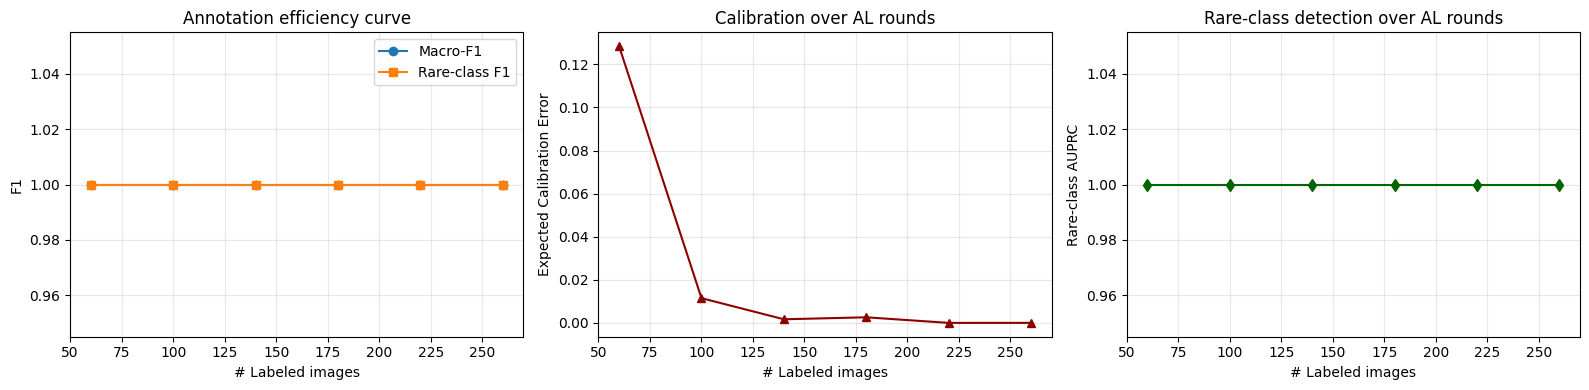

Saved plot to /content/drive/MyDrive/cse754/outputs/annotation_efficiency_curve.png


In [ ]:

n_labeled_hist = [r['n_labeled'] for r in results_log]
macro_f1_hist = [r['test']['macro_f1'] for r in results_log]
rare_f1_hist = [r['test']['rare_class_f1'] for r in results_log]
ece_hist = [r['test']['ece'] for r in results_log]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(n_labeled_hist, macro_f1_hist, marker='o', label='Macro-F1')
axes[0].plot(n_labeled_hist, rare_f1_hist, marker='s', label='Rare-class F1')
axes[0].set_xlabel('# Labeled images')
axes[0].set_ylabel('F1')
axes[0].set_title('Annotation efficiency curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(n_labeled_hist, ece_hist, marker='^', color='darkred')
axes[1].set_xlabel('# Labeled images')
axes[1].set_ylabel('Expected Calibration Error')
axes[1].set_title('Calibration over AL rounds')
axes[1].grid(alpha=0.3)

auprc_hist = [r['test']['rare_auprc'] for r in results_log]
axes[2].plot(n_labeled_hist, auprc_hist, marker='d', color='darkgreen')
axes[2].set_xlabel('# Labeled images')
axes[2].set_ylabel('Rare-class AUPRC')
axes[2].set_title('Rare-class detection over AL rounds')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(OUT_DIR, 'annotation_efficiency_curve.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print('Saved plot to', plot_path)


## 14. Ablation helper — compare acquisition strategies (random vs. entropy vs. margin vs. BALD vs. class-balanced BALD)

Runs a single scoring pass on the *current* unlabeled pool with the *current* model so you can sanity-check how differently each acquisition function ranks the pool, without re-running the full AL loop for each.

In [ ]:

def entropy_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    eps = 1e-12
    return -(mean_probs * np.log(mean_probs + eps)).sum(axis=1)

def margin_scores(mc_probs):
    mean_probs = mc_probs.mean(axis=0)
    sorted_probs = np.sort(mean_probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]
    return -margin  # smaller margin -> more informative -> higher score

def compare_acquisition_strategies(model, train_pool, unlabeled_idx, labeled_idx, cfg):
    if len(unlabeled_idx) == 0:
        print('No unlabeled examples left to compare.')
        return None
    pool_loader = make_loader(train_pool, unlabeled_idx, cfg.batch_size, shuffle=False)
    mc_probs = mc_dropout_predict(model, pool_loader, T=cfg.mc_passes, device=device)

    labeled_labels = get_labels(train_pool, labeled_idx)
    labeled_class_counts = np.bincount(labeled_labels, minlength=cfg.num_classes)

    strategies = {
        'random': np.random.RandomState(0).rand(len(unlabeled_idx)),
        'entropy': entropy_scores(mc_probs),
        'margin': margin_scores(mc_probs),
        'bald': bald_scores(mc_probs),
        'class_balanced_bald': class_balanced_bald(mc_probs, labeled_class_counts, cfg.class_balance_power),
    }

    pool_labels = get_labels(train_pool, unlabeled_idx)
    print(f"{'strategy':<22}{'rare% in top-B':>18}")
    B = min(cfg.acquisition_batch_size, len(unlabeled_idx))
    for name, scores in strategies.items():
        top_b = np.argsort(-scores)[:B]
        rare_pct = 100.0 * (pool_labels[top_b] == cfg.rare_class_idx).mean()
        print(f'{name:<22}{rare_pct:>17.1f}%')
    return strategies

_ = compare_acquisition_strategies(model, train_pool, unlabeled_idx, labeled_idx, cfg)


strategy                  rare% in top-B
random                              0.0%
entropy                             0.0%
margin                              0.0%
bald                                0.0%
class_balanced_bald                 0.0%


## 15. Save final model checkpoint to Drive

In [ ]:

final_ckpt_path = os.path.join(CKPT_DIR, 'rare_cell_model_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'config': cfg.__dict__,
    'labeled_idx': labeled_idx,
    'results_log': results_log,
}, final_ckpt_path)
print('Saved checkpoint to', final_ckpt_path)


Saved checkpoint to /content/drive/MyDrive/cse754/outputs/checkpoints/rare_cell_model_final.pt


## Notes / next steps

- **Swap in real data**: set `USE_SYNTHETIC_DATA = False` and populate
  `cse754/data/{train,val,test}/<class_name>/*.png` (single-cell crops, e.g. from
  SAM2 segmentation as in the proposal's preprocessing step). Everything downstream
  (backbone, LoRA, MC-Dropout head, class-balanced BALD, training loop, metrics)
  is dataset-agnostic and needs no changes.
- **Backbone ablations**: change `cfg.backbone_name` to `'facebook/dinov2-base'`,
  a CLIP checkpoint (`'openai/clip-vit-base-patch32'` — note different embedding
  extraction), or an MAE/ConvNeXt baseline via `timm` for the ablation studies
  in the proposal (Slide 30).
- **Uncertainty ablations**: swap `mc_dropout_predict` for a small deep ensemble
  (train K independently-initialized heads on the same frozen+LoRA backbone and
  average) to cross-check MC-Dropout calibration, as described in the proposal.
- **Cross-platform evaluation**: for the real-data setting, construct `val`/`test`
  splits by *source* (microscope/lab/batch) rather than random shuffling, per the
  proposal's cross-platform split design, to measure genuine domain-shift gap.
